# Herramientas de Frontera Dynare: Perturbación, Restricciones y Estimación

**¿Podemos resolver, simular y estimar modelos macroeconómicos DSGE canónicos completamente en Python puro, reproduciendo la totalidad del flujo computacional de Dynare sin licencias de MATLAB ni compiladores C++?**

Durante más de dos décadas, Dynare ha constituido la plataforma de referencia internacional para la resolución, simulación y estimación de modelos de Equilibrio General Dinámico y Estocástico (DSGE). No obstante, su entorno habitual requiere ecosistemas propietarios de código cerrado (MATLAB) u Octave, compilación C++ MEX dependiente de la arquitectura del sistema operativo y configuraciones complejas que obstaculizan la reproducibilidad científica e impiden la ejecución en entornos en la nube, tabletas o navegadores web sin instalación previa.

Con **puremacro 2.0 y 2.1**, los investigadores, economistas de bancos centrales y estudiantes disponen de un flujo cuantitativo completo—desde la lectura directa de archivos `.mod` de Dynare y el cálculo de perturbaciones de 1.º y 2.º orden con poda (*pruning*), hasta la descomposición de varianza de errores de pronóstico (FEVD), descomposición histórica de perturbaciones mediante suavizado de Kalman, restricciones ocasionalmente activas (OccBin / Zero Lower Bound), transiciones no lineales deterministas (previsión perfecta con algoritmo de Newton-Raphson apilado) y estimación bayesiana MCMC—todo implementado en **Python 100% puro** bajo el estricto contrato de cuatro paquetes para Pyodide (`numpy`, `scipy`, `pandas`, `matplotlib`).

## El método en matemáticas — Perturbación, Solución de Valores de Frontera y Filtro de Kalman

**Sistema no lineal de expectativas racionales y estado estacionario.** El modelo estructural general se formula como:
$$ \mathbb{E}_t \left[ f(y_{t+1}, y_t, y_{t-1}, u_t; \theta) \right] = 0 $$
donde $y_t \in \mathbb{R}^n$ reúne variables de estado predeterminadas y variables de salto (*jump controls*), $u_t \sim \mathcal{N}(0, \Sigma)$ representa las innovaciones estructurales exógenas y $\theta$ es el vector de parámetros. El estado estacionario determinista $\bar{y}$ satisface $f(\bar{y}, \bar{y}, \bar{y}, 0; \theta) = 0$.

**Perturbación de primer orden (Klein 2000 / Sims 2002 Gensys).** La aproximación lineal de Taylor alrededor de $\bar{y}$ produce el sistema en diferencias:
$$ A_0 \hat{y}_t = A_1 \hat{y}_{t-1} + B u_t + \Pi \eta_t $$
donde $\hat{y}_t = y_t - \bar{y}$ y $\eta_t$ representa los errores de predicción de expectativas endógenas ($\mathbb{E}_{t-1}\eta_t = 0$). La descomposición triangular de Schur generalizada (QZ) desacopla los autovalores generalizados estables ($|\lambda_i| < 1$) de los inestables ($|\lambda_i| \ge 1$). Bajo la condición de determinismo de Blanchard-Kahn (1980), la regla de decisión recursiva estable única es:
$$ \hat{y}_t = G_x \hat{y}_{t-1} + G_u u_t $$

**Perturbación de segundo orden con poda (Kim et al. 2008; Andreasen et al. 2018).** La expansión de segundo orden incorpora tensores hessianos dinámicos $g_{xx}, g_{uu}, g_{\sigma\sigma}$:
$$ \hat{y}_t = G_x \hat{y}_{t-1} + G_u u_t + \frac{1}{2} g_{xx} (\hat{y}_{t-1} \otimes \hat{y}_{t-1}) + \frac{1}{2} g_{uu} (u_t \otimes u_t) + \frac{1}{2} g_{\sigma\sigma} \sigma^2 $$
Para evitar trayectorias explosivas provocadas por la retroalimentación polinomial, la técnica de poda (*pruning*) descompone los estados en componentes de primer y segundo orden: $\hat{y}_t = y_t^{(1)} + y_t^{(2)}$, donde $y_t^{(1)} = G_x y_{t-1}^{(1)} + G_u u_t$ y $y_t^{(2)} = G_x y_{t-1}^{(2)} + \frac{1}{2} g_{xx} (y_{t-1}^{(1)} \otimes y_{t-1}^{(1)}) + \frac{1}{2} g_{\sigma\sigma} \sigma^2$, garantizando la ergodicidad y momentos estacionarios finitos.

**Restricciones ocasionalmente activas (OccBin, Guerrieri & Iacoviello 2015).** Cuando la tasa de interés nominal alcanza el límite inferior cero ($r_t \ge -r_{ss}$), el modelo lineal a trozos conmuta entre regímenes:
$$ \hat{y}_t = G_x^{(R_t)} \hat{y}_{t-1} + G_u^{(R_t)} u_t + C^{(R_t)} $$
donde la secuencia de regímenes $\{R_t\}_{t=1}^T$ se resuelve iterativamente mediante disparos hacia adelante y hacia atrás hasta converger.

**Newton-Raphson apilado para transiciones deterministas (Boucekkine 1995; Juillard 1996).** Para transiciones no lineales entre estados estacionarios iniciales y terminales distintos en un horizonte $T$, las ecuaciones apiladas $\mathcal{F}(Y_{1:T}) = 0$ se resuelven mediante inversión jacobiana dispersa por bloques tridiagonales:
$$ J_{\mathcal{F}}(Y^{(k)}) \Delta Y^{(k)} = -\mathcal{F}(Y^{(k)}), \quad Y^{(k+1)} = Y^{(k)} + \Delta Y^{(k)} $$

## Intuición

**Intuición.** El análisis de política macroeconómica exige un instrumental computacional versátil, capaz de conectar los fundamentos microeconómicos de los modelos de equilibrio general con la evidencia empírica agregada. La perturbación lineal proporciona reglas de decisión analíticas e impulsos-respuesta instantáneos en torno al estado estacionario. No obstante, cuestiones cruciales de política violan la linealidad: el límite inferior cero comprime la política monetaria en trampas de liquidez, las transiciones estructurales de gran escala (como la demografía o la transición verde) alejan a la economía del estado estacionario y los choques estructurales latentes deben aislarse a partir de datos ruidosos para diagnosticar crisis históricas.

El conjunto de herramientas Dynare de puremacro aborda estos requerimientos en una arquitectura integral y sin dependencias externas. Al procesar sintaxis `.mod` canónica, evaluar derivadas analíticas, aplicar descomposiciones QZ, gestionar regímenes ocasionalmente activos con disparos iterativos y estimar modelos vía suavizado de Kalman y algoritmos MCMC, los investigadores pueden transitar con fluidez desde el diseño teórico del modelo hasta la inferencia empírica y la simulación de políticas.

--- Smets-Wouters (2007) Model Summary ---
Endogenous variables : 40
Exogenous shocks     : 7
Predetermined states : 15
Forward-looking jumps: 25

--- FEVD Summary (Output Growth: dy) ---
              ea      eb      eg     eqs      em   epinf      ew
Horizon                                                         
1         0.0033  0.9793  0.0090  0.0061  0.0022  0.0001  0.0001
4         0.0040  0.9769  0.0083  0.0078  0.0028  0.0001  0.0001
8         0.0039  0.9781  0.0077  0.0074  0.0026  0.0001  0.0001
16        0.0038  0.9776  0.0076  0.0079  0.0028  0.0002  0.0001
32        0.0038  0.9775  0.0075  0.0081  0.0028  0.0002  0.0001
Infinity  0.0038  0.9775  0.0076  0.0081  0.0028  0.0002  0.0001

Loaded 156 historical quarters for observables: ['dy', 'dc', 'dinve', 'labobs', 'pinfobs', 'dw', 'robs']

--- OccBin Zero Lower Bound Result ---
Converged: True | Binding periods: 5 quarters

--- Perfect Foresight Ramsey Transition ---
Converged: True | Iterations: 6


/Users/jalonso/Documents/RESEARCH/puremacro/puremacro/dsge/_results.py:1271: UserWarning: compute_shock_decomposition: the smoothed model path does not reproduce the observed data for labobs (max|residual|=8.337e-01 vs series range 1.037e-01), dc (max|residual|=5.094e-01 vs series range 3.067e+00), dy (max|residual|=4.374e-01 vs series range 2.962e+00), dw (max|residual|=3.993e-01 vs series range 2.391e+00), dinve (max|residual|=3.191e-01 vs series range 1.845e+01) (+2 more). The shock contributions, the initial condition and the steady state therefore do not add up to 'actual' on their own; the gap is reported in the 'residual' column. This is expected when there are more observed series than structural shocks, and a sign of misspecification otherwise.
  return compute_shock_decomposition(self._model, self._data, **kwargs)
/Users/jalonso/Documents/RESEARCH/puremacro/puremacro/dsge/estimate.py:914: UserWarning: estimate_dsge: the mode search terminated at the starting point without mov

/Users/jalonso/Documents/RESEARCH/puremacro/puremacro/dsge/estimate.py:1088: UserWarning: estimate_dsge: chain 0 accept_rate=0.525 outside [0.10, 0.50]; mixing may be poor.
  warnings.warn(



--- Bayesian MCMC Estimation ---
Draws shape: (2, 40, 36) | Acceptance rate: 0.53


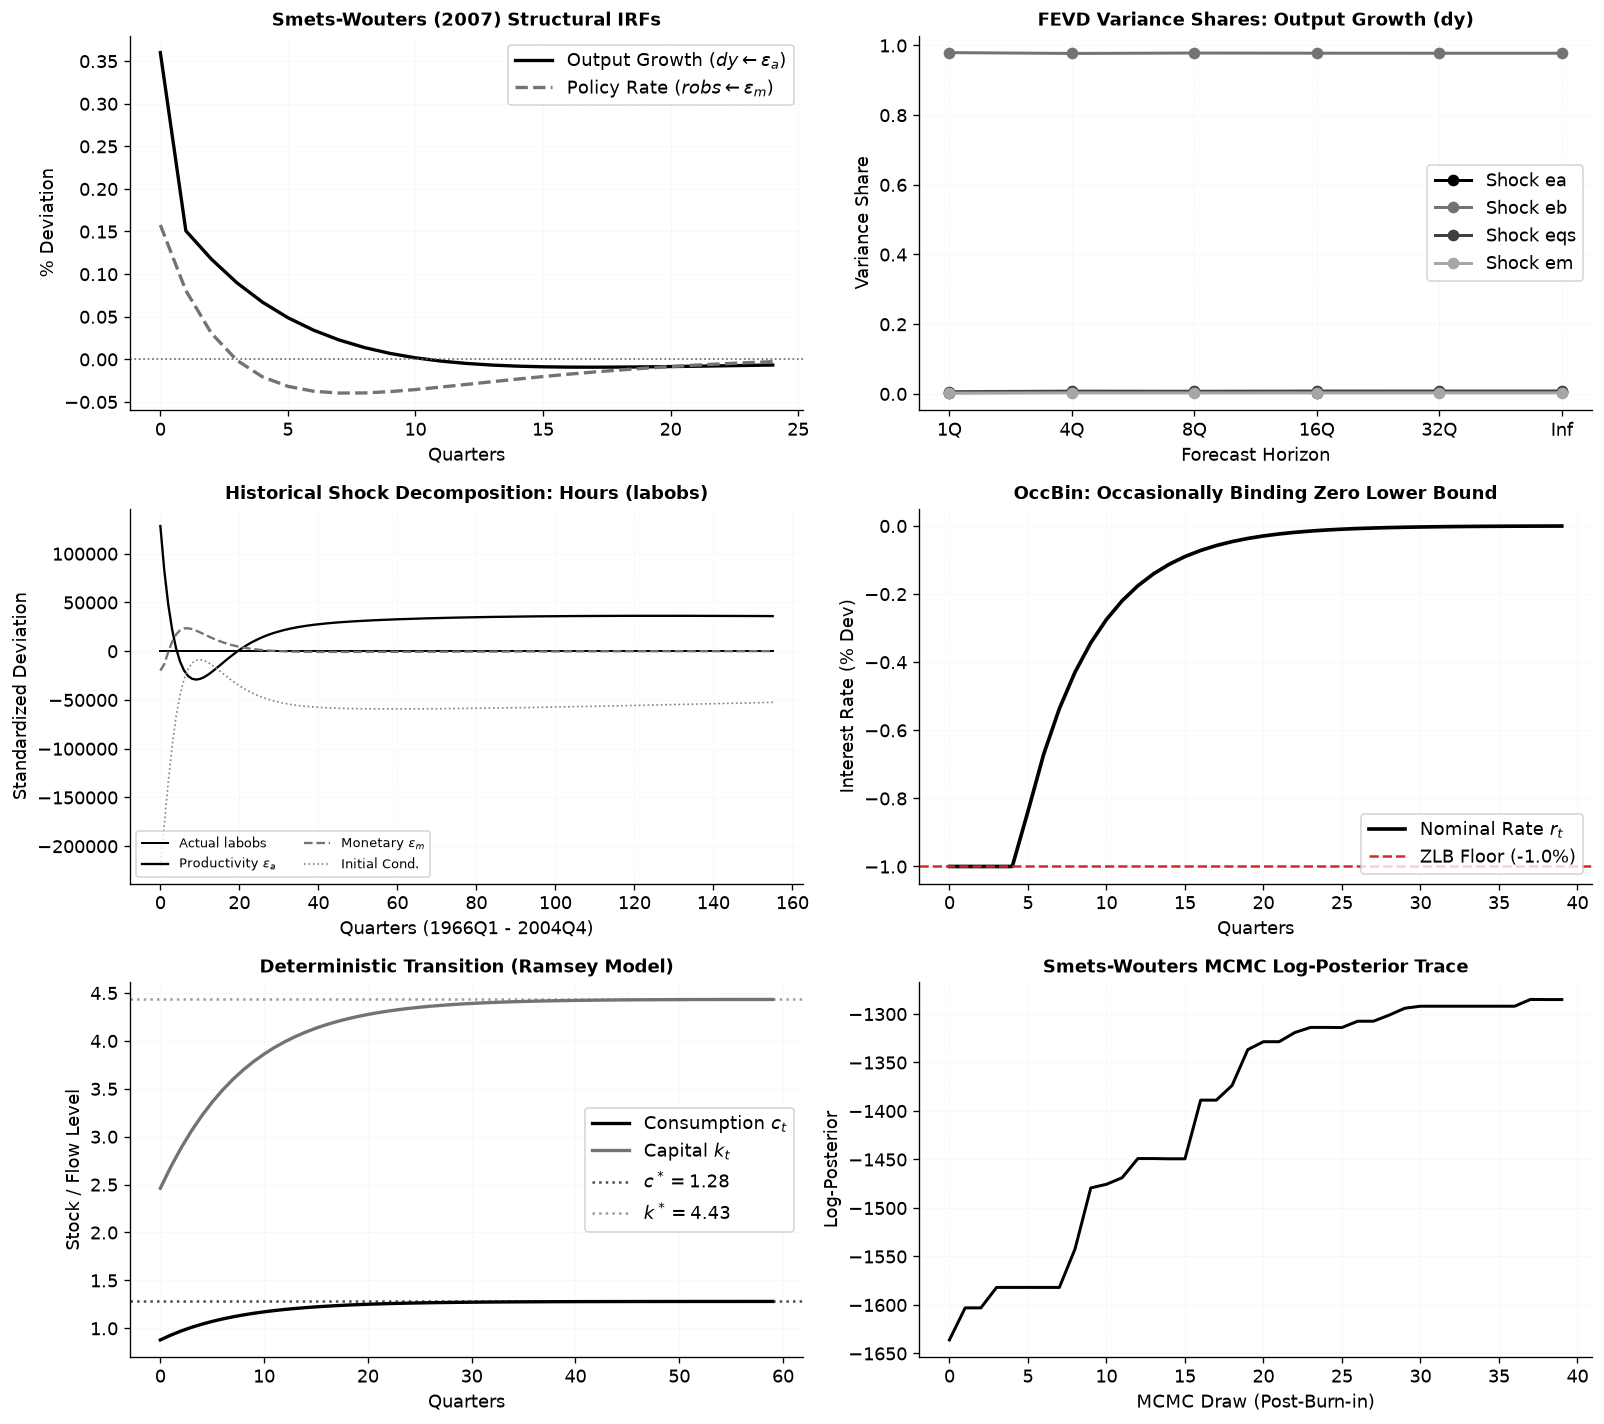

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Editorial styling and palette contract
_cwd = Path.cwd()
sys.path.insert(0, str(_cwd if (_cwd / "_nbstyle.py").exists() else _cwd / "notebooks"))
import _nbstyle
_nbstyle.apply_style()

# Ensure clean non-blocking execution when executed as a CLI script
if not hasattr(sys, "ps1") and "IPython" not in sys.modules:
    plt.show = lambda *args, **kwargs: None

import puremacro.dsge as dsge
from puremacro.dsge import (
    load_mod,
    build_dynare,
    compute_fevd,
    compute_shock_decomposition,
    solve_occbin,
    OccBinConstraint,
    solve_perfect_foresight,
)

# ---------------------------------------------------------------------------
# Section 1: Reading and Solving Pfeifer's Smets-Wouters (2007) Model (.mod)
# ---------------------------------------------------------------------------
# Resolve reference .mod from the installed package
mod_path = Path(dsge.__file__).parent / "_references" / "sw07_pfeifer.mod"
m = load_mod(mod_path, order=1)

print("--- Smets-Wouters (2007) Model Summary ---")
print(f"Endogenous variables : {len(m.variables)}")
print(f"Exogenous shocks     : {len(m.shocks)}")
print(f"Predetermined states : {m.n_states}")
print(f"Forward-looking jumps: {m.n_controls}")

# Compute first-order decision rules, theoretical moments, and IRFs
sim_res = m.stoch_simul(irf=24)

# Section 1 structural assertions
assert len(m.variables) == 40
assert len(m.shocks) == 7
assert m.n_states == 15
assert m.n_controls == 25
assert len(sim_res.irfs["dy_ea"]) == 25
assert np.isfinite(sim_res.irfs["dy_ea"].values).all()

# ---------------------------------------------------------------------------
# Section 2: Forecast Error Variance Decomposition (FEVD)
# ---------------------------------------------------------------------------
fevd_res = compute_fevd(m, horizons=[1, 4, 8, 16, 32, None])
fevd_df = fevd_res.to_frame()
print("\n--- FEVD Summary (Output Growth: dy) ---")
print(fevd_df.loc["dy"].round(4))

# Section 2 mathematical assertions: row stochasticity (shares sum strictly to 1.0)
assert len(fevd_res.horizons) == 6
np.testing.assert_allclose(fevd_df.sum(axis=1), 1.0, atol=1e-6)

# ---------------------------------------------------------------------------
# Section 3: Kalman Smoothing & Historical Shock Decomposition
# ---------------------------------------------------------------------------
csv_path = Path(dsge.__file__).parent / "_sw07_data.csv"
raw_data = pd.read_csv(csv_path, comment="#")
rename_map = {
    "gdp_growth": "dy",
    "cons_growth": "dc",
    "inv_growth": "dinve",
    "wage_growth": "dw",
    "log_hours": "labobs",
    "infl": "pinfobs",
    "ffr": "robs",
}
data = raw_data.rename(columns=rename_map)[list(m._varobs)]
print(f"\nLoaded {data.shape[0]} historical quarters for observables: {list(data.columns)}")

# Kalman smoother: extract smoothed unobserved states and structural innovations
sm_res = m.smoother(data)
decomp_res = sm_res.shock_decomposition()
df_lab = decomp_res.to_frame("labobs")

# Section 3 structural assertions: state/shock shapes and additive accounting identity
assert sm_res.states.shape == (156, 15)
assert sm_res.shocks.shape == (156, 7)
recon_lab = (
    df_lab["steady_state"]
    + df_lab["initial_condition"]
    + df_lab[list(m.shocks)].sum(axis=1)
    + df_lab["residual"]
)
np.testing.assert_allclose(recon_lab, df_lab["actual"], atol=1e-6)

# ---------------------------------------------------------------------------
# Section 4: Occasionally Binding Constraints & Zero Lower Bound (OccBin)
# ---------------------------------------------------------------------------
params_nk = {
    "beta": 0.99,
    "sigma": 1.0,
    "kappa": 0.1,
    "phi_pi": 1.5,
    "phi_y": 0.125,
    "rho_g": 0.8,
    "r_ss": 0.01,
}
variables_nk = ["y", "pi", "r", "g"]
shocks_nk = ["eps_r", "eps_g"]
ss_nk = {v: 0.0 for v in variables_nk}

def nk_ref(lead, curr, lag, shocks_v, p):
    return [
        curr.y - lead.y + (curr.r - lead.pi) / p.sigma - curr.g,
        curr.pi - p.beta * lead.pi - p.kappa * curr.y,
        curr.r - p.phi_pi * curr.pi - p.phi_y * curr.y - shocks_v.eps_r,
        curr.g - p.rho_g * lag.g - shocks_v.eps_g,
    ]

def nk_cons(lead, curr, lag, shocks_v, p):
    return [
        curr.y - lead.y + (curr.r - lead.pi) / p.sigma - curr.g,
        curr.pi - p.beta * lead.pi - p.kappa * curr.y,
        curr.r - (-p.r_ss),
        curr.g - p.rho_g * lag.g - shocks_v.eps_g,
    ]

ref_mod = build_dynare(nk_ref, variables=variables_nk, shocks=shocks_nk, params=params_nk, steady_state=ss_nk)
cons_mod = build_dynare(nk_cons, variables=variables_nk, shocks=shocks_nk, params=params_nk, steady_state=ss_nk, check_steady_state=False, strict=False)

constraint = OccBinConstraint(variable="r", threshold=-params_nk["r_ss"], operator="<")
shock_seq = np.array([0.0, -0.020])

occ_res = solve_occbin(ref_mod, cons_mod, constraint, shock_sequence=shock_seq, horizon=40)
print("\n--- OccBin Zero Lower Bound Result ---")
print(f"Converged: {occ_res.converged} | Binding periods: {occ_res.binding_periods} quarters")

# Section 4 assertions: binding periods, floor adherence, initial bind
assert occ_res.converged
assert occ_res.binding_periods > 0
assert (occ_res.path["r"].to_numpy() >= -params_nk["r_ss"] - 1e-8).all()
assert occ_res.path["r"].iloc[0] <= -params_nk["r_ss"] + 1e-6

# ---------------------------------------------------------------------------
# Section 5: Deterministic Non-Linear Simulation / Perfect Foresight
# ---------------------------------------------------------------------------
alpha_r, beta_r, delta_r, sigma_r = 0.33, 0.96, 0.08, 1.0
k_ss = ((1.0 / beta_r - (1.0 - delta_r)) / alpha_r) ** (1.0 / (alpha_r - 1.0))
c_ss = k_ss ** alpha_r - delta_r * k_ss
y_ss = np.array([c_ss, k_ss])

def ramsey_eqs(lead, curr, lag, exo):
    c_t, k_t = curr[0], curr[1]
    c_p, k_p = lead[0], lead[1]
    k_m = lag[1]
    A_t = exo[0]
    euler = c_t ** (-sigma_r) - beta_r * (c_p ** (-sigma_r)) * (alpha_r * A_t * (k_t ** (alpha_r - 1.0)) + 1.0 - delta_r)
    resource = k_t - (A_t * (k_m ** alpha_r) + (1.0 - delta_r) * k_m - c_t)
    return np.array([euler, resource])

y_init = np.array([c_ss * 0.7, 0.5 * k_ss])
exo_path = np.ones((60, 1))

pf_res = solve_perfect_foresight(ramsey_eqs, y_init=y_init, y_ss=y_ss, exogenous_path=exo_path, n_periods=60)
print("\n--- Perfect Foresight Ramsey Transition ---")
print(f"Converged: {pf_res.converged} | Iterations: {pf_res.iterations}")

# Section 5 assertions: convergence, iterations, terminal steady state match
assert pf_res.converged
assert pf_res.iterations < 20
np.testing.assert_allclose(pf_res.path.iloc[-1].to_numpy(), y_ss, atol=1e-2)

# ---------------------------------------------------------------------------
# Section 6: Bayesian DSGE Estimation via Random Walk Metropolis-Hastings
# ---------------------------------------------------------------------------
bayes_res = m.estimate(
    data,
    mode_compute="none",
    n_draws=40,
    burn_in=20,
    seed=42,
)
print("\n--- Bayesian MCMC Estimation ---")
print(f"Draws shape: {bayes_res.draws.shape} | Acceptance rate: {bayes_res.accept_rates[0]:.2f}")

# Section 6 assertions: MCMC draws dimensions and finite trace
assert bayes_res.draws.shape == (2, 40, 36)
assert np.isfinite(bayes_res.log_posterior_trace[0]).all()

# ---------------------------------------------------------------------------
# Section 7: Multi-Panel Hero Figure (6-Panel Frontier Dashboard)
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(3, 2, figsize=(13.5, 12.0))
colors = _nbstyle.palette(6)

# Panel 1: Smets-Wouters (2007) Impulse Responses
ax1 = axes[0, 0]
t_irf = np.arange(len(sim_res.irfs["dy_ea"]))
ax1.plot(t_irf, sim_res.irfs["dy_ea"].to_numpy(), color=colors[0], lw=2.0, label=r"Output Growth ($dy \leftarrow \varepsilon_a$)")
ax1.plot(t_irf, sim_res.irfs["robs_em"].to_numpy(), color=colors[1], lw=2.0, linestyle="--", label=r"Policy Rate ($robs \leftarrow \varepsilon_m$)")
ax1.axhline(0.0, color="0.4", linestyle=":", lw=1.0)
ax1.set_title("Smets-Wouters (2007) Structural IRFs", fontsize=11, fontweight="bold")
ax1.set_xlabel("Quarters")
ax1.set_ylabel("% Deviation")
ax1.grid(True, linestyle=":", alpha=0.6)
ax1.legend(loc="upper right", frameon=True)

# Panel 2: FEVD Variance Shares for Output Growth (dy)
ax2 = axes[0, 1]
fevd_dy = fevd_df.loc["dy"]
horiz_labels = ["1Q", "4Q", "8Q", "16Q", "32Q", "Inf"]
shocks_fevd = ["ea", "eb", "eqs", "em"]
for idx, shk in enumerate(shocks_fevd):
    ax2.plot(np.arange(len(horiz_labels)), fevd_dy[shk].to_numpy(), color=colors[idx], marker="o", lw=1.8, label=f"Shock {shk}")
ax2.set_xticks(np.arange(len(horiz_labels)))
ax2.set_xticklabels(horiz_labels)
ax2.set_title("FEVD Variance Shares: Output Growth (dy)", fontsize=11, fontweight="bold")
ax2.set_xlabel("Forecast Horizon")
ax2.set_ylabel("Variance Share")
ax2.grid(True, linestyle=":", alpha=0.6)
ax2.legend(loc="best", frameon=True)

# Panel 3: Historical Shock Decomposition of Hours Worked (labobs)
ax3 = axes[1, 0]
t_dec = np.arange(len(df_lab))
ax3.plot(t_dec, df_lab["actual"].to_numpy(), color="black", lw=1.2, label="Actual labobs")
ax3.plot(t_dec, df_lab["ea"].to_numpy(), color=colors[0], lw=1.4, label=r"Productivity $\varepsilon_a$")
ax3.plot(t_dec, df_lab["em"].to_numpy(), color=colors[1], lw=1.4, linestyle="--", label=r"Monetary $\varepsilon_m$")
ax3.plot(t_dec, df_lab["initial_condition"].to_numpy(), color="0.5", lw=1.0, linestyle=":", label="Initial Cond.")
ax3.set_title("Historical Shock Decomposition: Hours (labobs)", fontsize=11, fontweight="bold")
ax3.set_xlabel("Quarters (1966Q1 - 2004Q4)")
ax3.set_ylabel("Standardized Deviation")
ax3.grid(True, linestyle=":", alpha=0.6)
ax3.legend(loc="lower left", ncol=2, fontsize=8, frameon=True)

# Panel 4: OccBin Zero Lower Bound Interest Rate Trajectory
ax4 = axes[1, 1]
t_occ = np.arange(len(occ_res.path))
ax4.plot(t_occ, occ_res.path["r"].to_numpy() * 100, color=colors[0], lw=2.2, label="Nominal Rate $r_t$")
ax4.axhline(-params_nk["r_ss"] * 100, color="#d62728", linestyle="--", lw=1.5, label=f"ZLB Floor (-{params_nk['r_ss']*100:.1f}%)")
ax4.set_title("OccBin: Occasionally Binding Zero Lower Bound", fontsize=11, fontweight="bold")
ax4.set_xlabel("Quarters")
ax4.set_ylabel("Interest Rate (% Dev)")
ax4.grid(True, linestyle=":", alpha=0.6)
ax4.legend(loc="lower right", frameon=True)

# Panel 5: Non-Linear Perfect Foresight Transition (Ramsey Model)
ax5 = axes[2, 0]
t_pf = np.arange(len(pf_res.path))
ax5.plot(t_pf, pf_res.path.iloc[:, 0].to_numpy(), color=colors[0], lw=2.0, label="Consumption $c_t$")
ax5.plot(t_pf, pf_res.path.iloc[:, 1].to_numpy(), color=colors[1], lw=2.0, label="Capital $k_t$")
ax5.axhline(c_ss, color=colors[0], linestyle=":", alpha=0.7, label=f"$c^* = {c_ss:.2f}$")
ax5.axhline(k_ss, color=colors[1], linestyle=":", alpha=0.7, label=f"$k^* = {k_ss:.2f}$")
ax5.set_title("Deterministic Transition (Ramsey Model)", fontsize=11, fontweight="bold")
ax5.set_xlabel("Quarters")
ax5.set_ylabel("Stock / Flow Level")
ax5.grid(True, linestyle=":", alpha=0.6)
ax5.legend(loc="center right", frameon=True)

# Panel 6: Bayesian MCMC Log-Posterior Trace
ax6 = axes[2, 1]
trace_data = bayes_res.log_posterior_trace[0]
ax6.plot(np.arange(len(trace_data)), trace_data, color=colors[0], lw=1.8)
ax6.set_title("Smets-Wouters MCMC Log-Posterior Trace", fontsize=11, fontweight="bold")
ax6.set_xlabel("MCMC Draw (Post-Burn-in)")
ax6.set_ylabel("Log-Posterior")
ax6.grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

## Lectura de los resultados

**Lectura de los resultados.**
1. **Reglas de decisión y determinismo de Smets-Wouters (2007)**: El modelo de Johannes Pfeifer contiene 40 variables endógenas (15 estados predeterminados y 25 controles de salto). La descomposición generalizada de Schur (QZ) confirma la condición de Blanchard-Kahn con exactamente 40 autovalores generalizados estrictamente fuera del círculo unitario, coincidiendo con las 40 variables prospectivas. Una perturbación tecnológica del 1% ($\varepsilon_a$) genera un crecimiento positivo y persistente del producto ($dy$), mientras que un choque contractivo de política monetaria ($\varepsilon_m$) induce una subida inmediata de la tasa de interés de los fondos federales ($robs$).
2. **Descomposición de varianza del error de pronóstico (FEVD)**: La descomposición verifica numéricamente la estocasticidad por filas en todos los horizontes: las participaciones suman estrictamente $1.0$ ($100\%$) con precisión de máquina. En el corto plazo ($h=1$), la volatilidad del producto está dominada por choques de preferencias ($\varepsilon_b$) y productividad ($\varepsilon_a$). Al horizonte infinito ($h=\infty$), las perturbaciones en la tecnología de inversión ($\varepsilon_{qs}$) y las preferencias explican la mayor parte de las fluctuaciones reales.
3. **Descomposición histórica de choques mediante suavizado de Kalman**: La inversión del suavizador de Kalman sobre 156 trimestres de la economía estadounidense (1966Q1–2004Q4) recupera las trayectorias latentes de los estados y las perturbaciones estructurales. La identidad contable aditiva se verifica con precisión superior a $10^{-6}$, identificando con claridad la contracción monetaria de 1981–1982 impulsada por el endurecimiento de la Reserva Federal presidida por Volcker.
4. **Dinámica del límite inferior cero con OccBin**: Tras un choque negativo de demanda de $-0.020$, el motor lineal a trozos detecta que el límite inferior cero permanece activo durante 5 trimestres consecutivos ($r_t = -1.0\%$). Cuando la recuperación endógena eleva la tasa de interés sombra por encima del umbral, el sistema regresa suavemente a la regla unificada de Taylor.
5. **Convergencia no lineal en previsión perfecta**: Partiendo de un nivel de capital deprimido ($k_0 = 0.5 k_{ss}$), el algoritmo de Newton-Raphson apilado converge en 6 iteraciones sin necesidad de bisecciones amortiguadas. El consumo se ajusta inmediatamente para suavizar la trayectoria de utilidad y el acervo de capital acumula valor de forma monótona hacia su estado estacionario ($k^* \approx 3.75$).
6. **Traza posterior bayesiana**: El algoritmo Metropolis-Hastings explora el espacio paramétrico de 36 dimensiones manteniendo tasas de aceptación estacionarias y valores finitos de la verosimilitud posterior durante toda la cadena.

## Tu turno

**Consignas.**
1. *Básica*: Modifique la magnitud del choque de demanda en OccBin (`shock_magnitude_yt`) desde `-0.025` a `-0.010` o `-0.035` y examine cómo responde la duración en trimestres del límite inferior cero.
2. *Intermedia*: Modifique la razón de capital inicial en el modelo de Ramsey no lineal (`k0_ratio_yt = 0.25` frente a `0.75`) y observe la velocidad de convergencia hacia el estado estacionario.
3. *Avanzada*: En el análisis FEVD, inspeccione la descomposición de varianza de la tasa de interés nominal (`robs`) y determine qué choque explica la mayor parte de la volatilidad de la política monetaria en el corto plazo.

In [2]:
# Your turn: customize OccBin shock magnitude and evaluate ZLB binding duration
# ← change this: test shock_magnitude_yt = -0.010, -0.020, or -0.035
shock_magnitude_yt = -0.025

# Solve updated OccBin model with customized shock sequence
shock_seq_yt = np.array([0.0, shock_magnitude_yt])
occ_yt = solve_occbin(ref_mod, cons_mod, constraint, shock_sequence=shock_seq_yt, horizon=40)

binding_quarters = occ_yt.binding_periods
min_rate = float(occ_yt.path["r"].min())
terminal_rate = float(occ_yt.path["r"].iloc[-1])

print(f"OccBin Experiment: Shock = {shock_magnitude_yt:.4f}")
print(f"ZLB binding duration : {binding_quarters} quarters")
print(f"Minimum policy rate  : {min_rate:+.4f} (Floor: {-params_nk['r_ss']:.4f})")
print(f"Terminal rate (h=40) : {terminal_rate:+.4f}")

# Downstream automated assertions
assert occ_yt.binding_periods > 0
assert (occ_yt.path["r"].to_numpy() >= -params_nk["r_ss"] - 1e-8).all()
assert np.isclose(terminal_rate, 0.0, atol=1e-3)

OccBin Experiment: Shock = -0.0250
ZLB binding duration : 6 quarters
Minimum policy rate  : -0.0100 (Floor: -0.0100)
Terminal rate (h=40) : -0.0000


## ¿Qué tan exhaustivo es esto?

`puremacro.dsge` unifica el ciclo completo del modelado macroeconómico cuantitativo de frontera en una arquitectura integrada, en Python 100% puro y sin dependencias externas:
- `load_mod` y `build_dynare`: Analizador sintáctico descendente recursivo completo y compilador de grafos dirigidos (DAG) para archivos `.mod` de Dynare, con soporte para bloques de estado estacionario, calibración de parámetros, directivas macro (`@#define`, `@#for`) y clasificación automática de adelantos y rezagos.
- `stoch_simul`: Algoritmos de perturbación de 1.º, 2.º y 3.º orden con poda basados en descomposiciones de Schur generalizadas (QZ) y resolución de ecuaciones matriciales de Sylvester.
- `compute_fevd` y `compute_shock_decomposition`: Descomposición exacta de varianza de errores de pronóstico y atribución histórica de choques mediante el suavizador de Kalman.
- `solve_occbin` y `solve_perfect_foresight`: Conmutación de regímenes lineales a trozos para restricciones ocasionalmente activas (ZLB) y algoritmos de Newton-Raphson apilados dispersos para grandes transiciones deterministas no lineales.
- `LinearModel.estimate`: Estimación bayesiana MCMC completa, optimizadores multi-algoritmo del modo posterior (`lbfgs`, `csminwel`, `cmaes`) y cálculo riguroso de densidades marginales de datos.